# Netflix Stock - Exploratory Data Analysis (EDA)

An analysis of Netflix (NFLX) stock prices from 2002 to 2026.

---

## Dataset Description

This dataset contains **daily Netflix (NFLX) stock market data** from **2002 to 2026**.

- **Source:** Yahoo Finance
- **Records:** 5,961 trading days
- **Main features:** `Open`, `High`, `Low`, `Close`, `Volume`
- **Time index:** Trading date (`Date`)

### 
- `Open`: Price at market open
- `High`: Highest price during the day
- `Low`: Lowest price during the day
- `Close`: Price at market close
- `Volume`: Number of shares traded

## 1. Import Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries loaded!')

Libraries loaded!


---
## 2. Load and Inspect Data

In [51]:
# Load dataset
df = pd.read_csv('datasets/netflix_stock.csv', header=[0, 1], index_col=0)
df.columns = df.columns.get_level_values(0)
df.index = pd.to_datetime(df.index)
df.index.name = 'Date'

print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded: 5961 rows, 5 columns


### 2.1 First Rows

In [52]:
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000
2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000
2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000
2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000
2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000


### 2.2 Last Rows

In [53]:
df.tail()

Price,Close,High,Low,Open,Volume
Date,,,,,
2026-01-26,85.699997,86.940002,85.349998,86.919998,40941900
2026-01-27,85.580002,85.599998,83.879997,85.279999,37790800
2026-01-28,84.639999,86.470001,84.300003,85.629997,37762600
2026-01-29,83.160004,84.379997,82.349998,84.309998,42278100
2026-01-30,83.489998,84.059998,82.779999,83.099998,45755000


### 2.3 Data Info

In [54]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5961 entries, 2002-05-23 to 2026-01-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5961 non-null   float64
 1   High    5961 non-null   float64
 2   Low     5961 non-null   float64
 3   Open    5961 non-null   float64
 4   Volume  5961 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 279.4 KB


### 2.4 Statistical Summary

In [55]:
df.describe()

Price,Close,High,Low,Open,Volume
count,5961.000000,5961.000000,5961.000000,5961.000000,5.961000e+03
mean,19.814843,20.092718,19.521450,19.811342,1.485302e+08
std,27.859933,28.205467,27.491630,27.858355,1.821948e+08
min,0.037286,0.041071,0.034643,0.037786,2.856000e+06
25%,0.440571,0.448714,0.430143,0.438571,5.201600e+07
50%,5.081000,5.194000,5.001429,5.085714,9.113700e+07
75%,33.785999,34.241001,33.183998,33.723000,1.774710e+08
max,133.912994,134.115005,132.121002,133.822998,3.234140e+09


---
## 3. Data Quality Check

In [56]:
# Missing values
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [57]:
# Duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


In [58]:
# Date range
print(f'Start date: {df.index.min()}')
print(f'End date: {df.index.max()}')
print(f'Total days: {len(df)}')

Start date: 2002-05-23 00:00:00
End date: 2026-01-30 00:00:00
Total days: 5961


---
## 4. Basic Visualizations

### 4.1 Stock Price Over Time

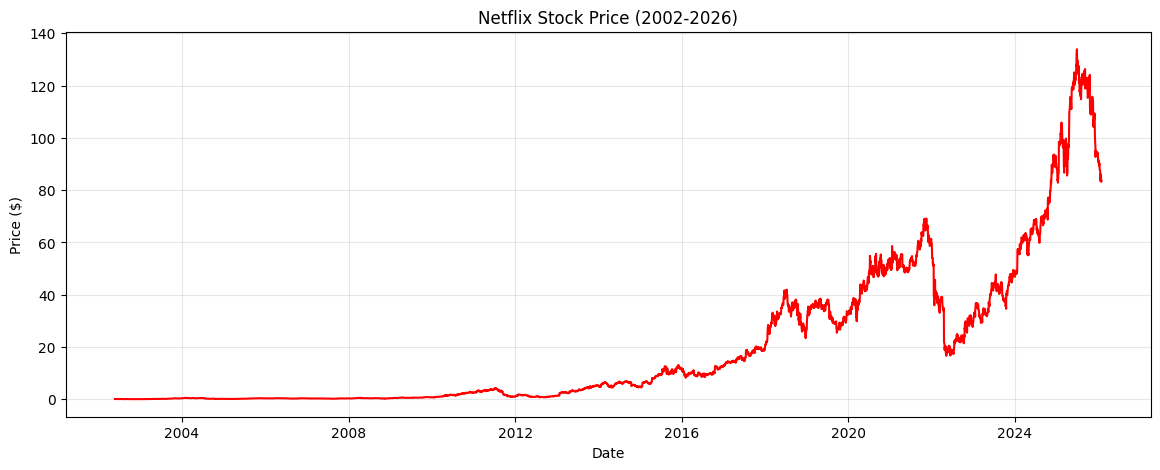

In [59]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='red')
plt.title('Netflix Stock Price (2002-2026)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)
plt.show()

### 4.2 Trading Volume

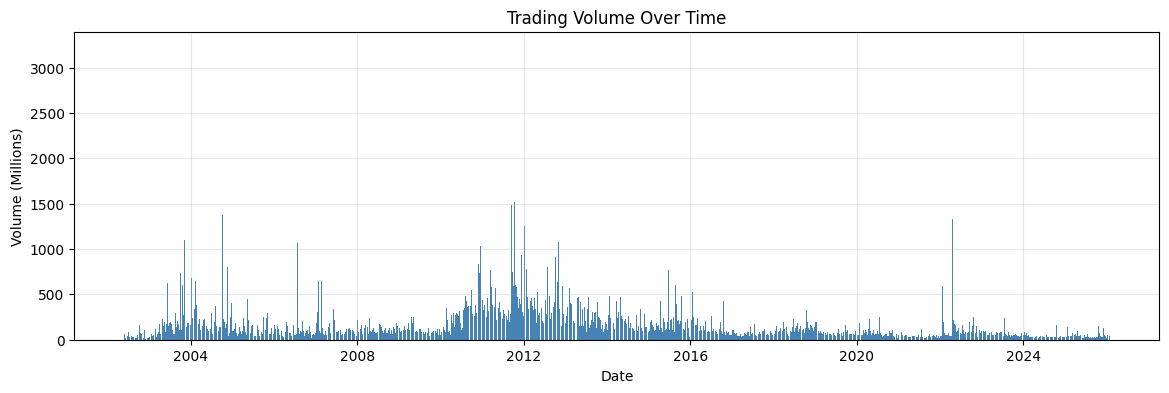

In [60]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'] / 1e6, color='steelblue', width=2)
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume (Millions)')
plt.grid(True, alpha=0.3)
plt.show()

### 4.3 Moving Averages

Moving averages smooth out price data to show trends more clearly.

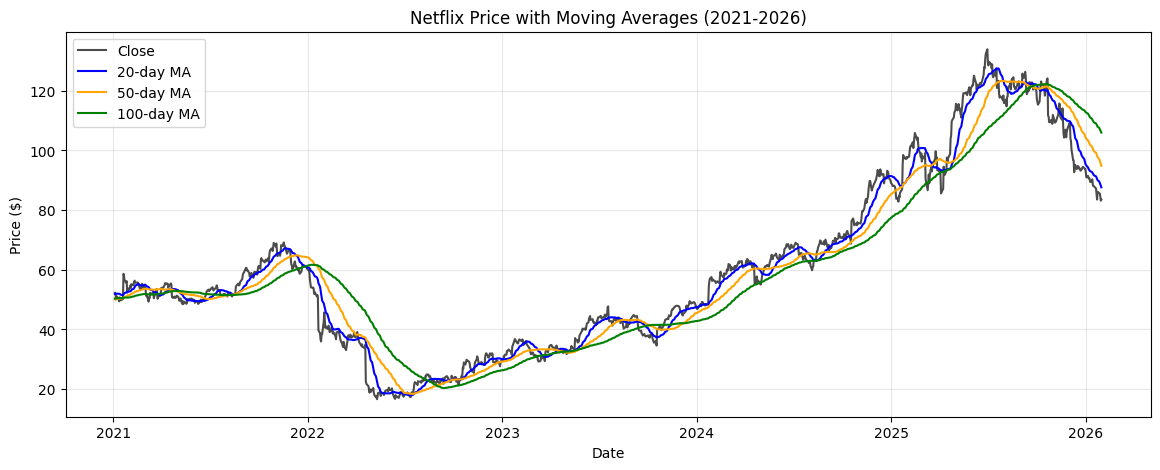

In [61]:
# Calculate moving averages
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

df['MA_100'] = df['Close'].rolling(window=100).mean()

# Plot price with moving averages (last 5 years for clarity)
recent = df[df.index >= '2021-01-01']

plt.figure(figsize=(14, 5))
plt.plot(recent.index, recent['Close'], label='Close', color='black', alpha=0.7)
plt.plot(recent.index, recent['MA_20'], label='20-day MA', color='blue')
plt.plot(recent.index, recent['MA_50'], label='50-day MA', color='orange')
plt.plot(recent.index, recent['MA_100'], label='100-day MA', color='green')
plt.title('Netflix Price with Moving Averages (2021-2026)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 5. Daily Returns Analysis

In [62]:
# Calculate daily returns (percentage change)
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Daily_Return'].head(10)

Date
2002-05-23         NaN
2002-05-24    1.134205
2002-05-28   -4.368596
2002-05-29   -4.629515
2002-05-30   -2.912368
2002-05-31    0.466667
2002-06-03    4.843788
2002-06-04   -0.948987
2002-06-05    2.619287
2002-06-06    3.051066
Name: Daily_Return, dtype: float64

### 5.1 Returns Distribution (Histogram)

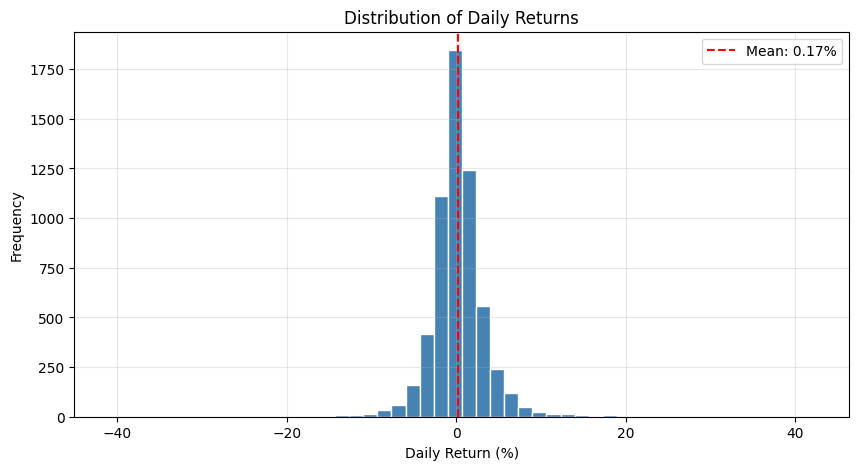

In [63]:
plt.figure(figsize=(10, 5))
plt.hist(df['Daily_Return'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.axvline(df['Daily_Return'].mean(), color='red', linestyle='--', label=f'Mean: {df["Daily_Return"].mean():.2f}%')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5.2 Basic Statistics

In [64]:
returns = df['Daily_Return'].dropna()

print('Daily Return Statistics:')
print(f'  Mean:   {returns.mean():.3f}%')
print(f'  Median: {returns.median():.3f}%')
print(f'  Std:    {returns.std():.3f}%')
print(f'  Min:    {returns.min():.2f}%')
print(f'  Max:    {returns.max():.2f}%')

Daily Return Statistics:
  Mean:   0.170%
  Median: 0.035%
  Std:    3.442%
  Min:    -40.91%
  Max:    42.22%


---
## 6. More Data Exploration

### 6.1 Daily Price Range

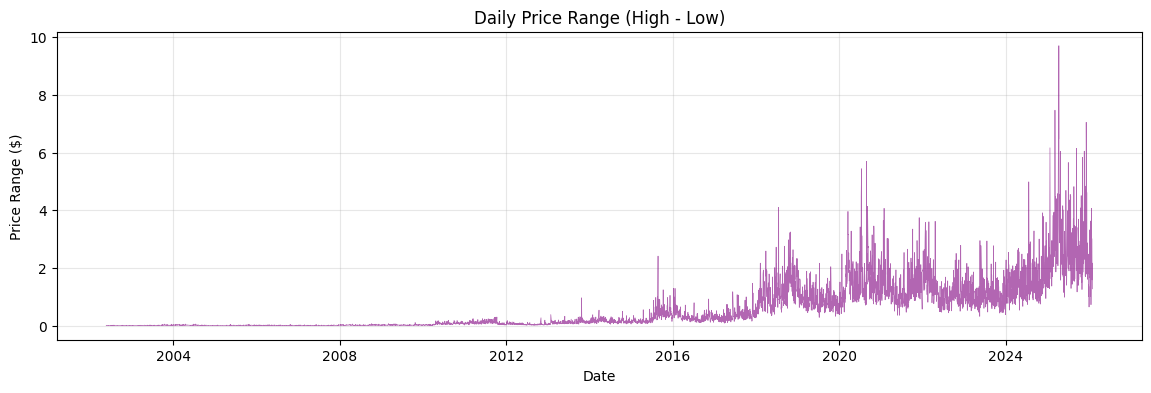

In [65]:
# Daily price range (High - Low)
df['Price_Range'] = df['High'] - df['Low']

plt.figure(figsize=(14, 4))
plt.plot(df.index, df['Price_Range'], color='purple', alpha=0.6, linewidth=0.5)
plt.title('Daily Price Range (High - Low)')
plt.xlabel('Date')
plt.ylabel('Price Range ($)')
plt.grid(True, alpha=0.3)
plt.show()

### 6.2 Yearly Price Comparison

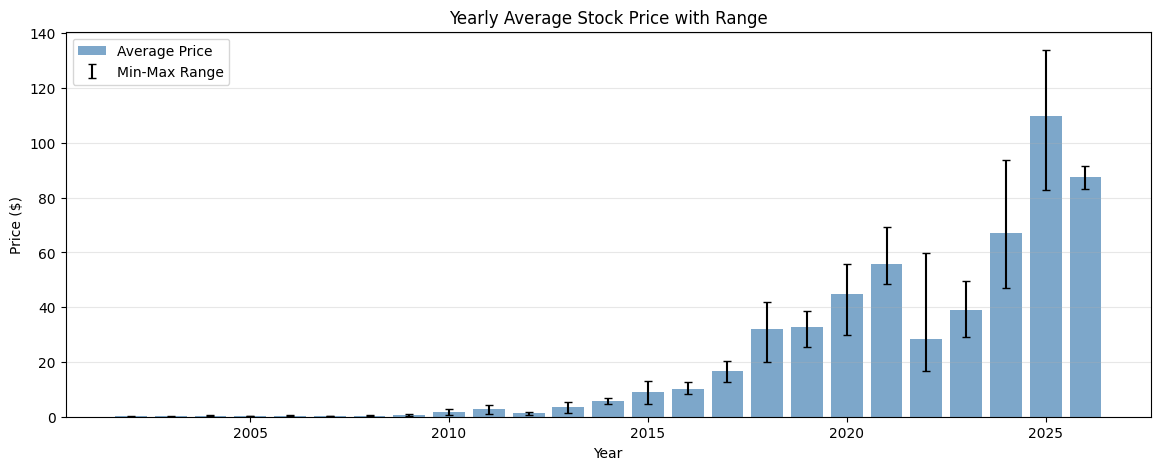

In [66]:
# Extract year and calculate yearly statistics
df['Year'] = df.index.year
yearly_stats = df.groupby('Year')['Close'].agg(['mean', 'min', 'max'])

plt.figure(figsize=(14, 5))
plt.bar(yearly_stats.index, yearly_stats['mean'], color='steelblue', alpha=0.7, label='Average Price')
plt.errorbar(yearly_stats.index, yearly_stats['mean'], 
             yerr=[yearly_stats['mean']-yearly_stats['min'], yearly_stats['max']-yearly_stats['mean']], 
             fmt='none', color='black', capsize=3, label='Min-Max Range')
plt.title('Yearly Average Stock Price with Range')
plt.xlabel('Year')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

### 6.3 Open vs Close Price

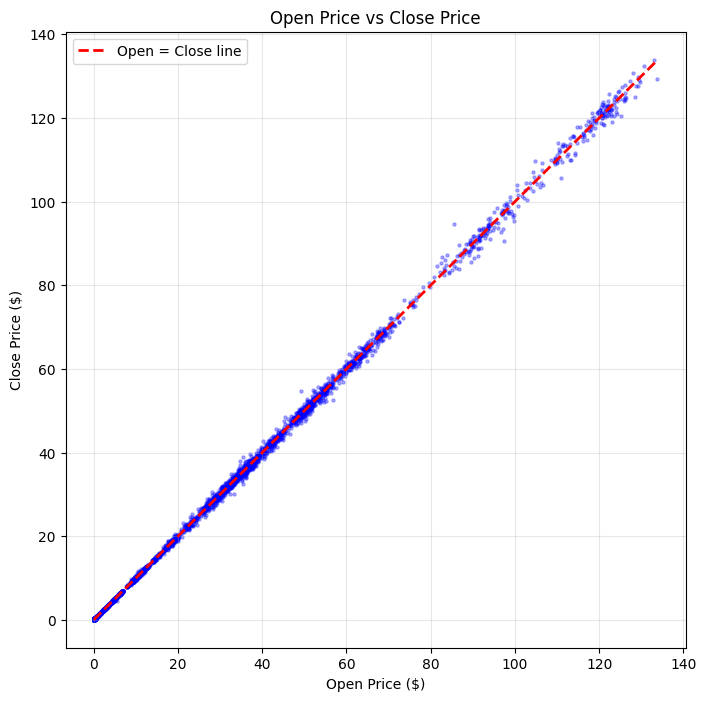

In [67]:
# Open vs Close scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(df['Open'], df['Close'], alpha=0.3, s=5, color='blue')
plt.plot([df['Open'].min(), df['Open'].max()], [df['Open'].min(), df['Open'].max()], 
         'r--', linewidth=2, label='Open = Close line')
plt.title('Open Price vs Close Price')
plt.xlabel('Open Price ($)')
plt.ylabel('Close Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6.4 Returns by Day of Week

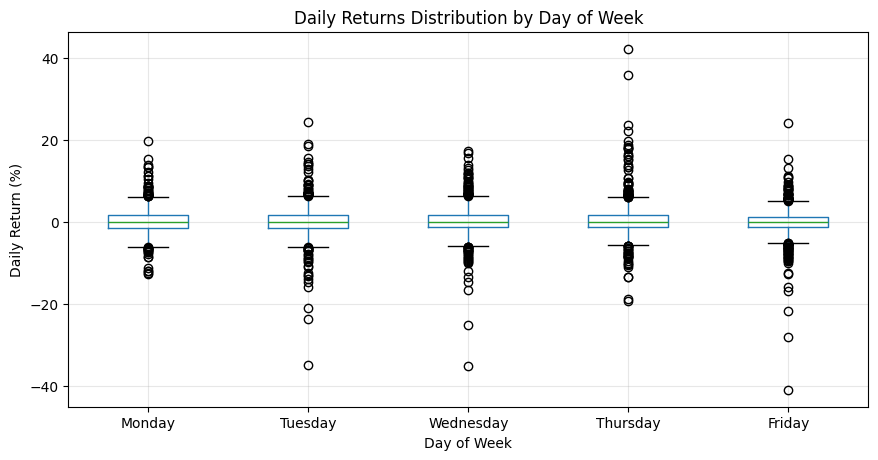

In [68]:
# Returns distribution by day of week
df['DayOfWeek'] = df.index.dayofweek
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='Daily_Return', by='DayOfWeek', ax=ax)
ax.set_xticklabels(day_names)
ax.set_title('Daily Returns Distribution by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Daily Return (%)')
plt.suptitle('')  # Remove automatic title
plt.grid(True, alpha=0.3)
plt.show()

---
## 7. Correlation Analysis

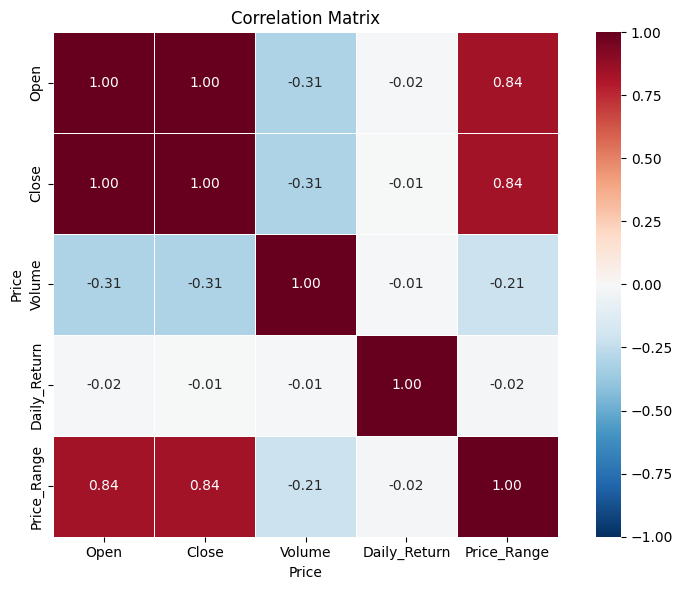

In [69]:
# Correlation between key metrics
corr_cols = ['Open', 'Close', 'Volume', 'Daily_Return', 'Price_Range']

corr_matrix = df[corr_cols].dropna().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', 
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 8. Summary

In [70]:
print('=== DATASET SUMMARY ===')
print(f'Period: {df.index.min().date()} to {df.index.max().date()}')
print(f'Records: {len(df)}')
print(f'Min Price: ${df["Close"].min():.2f}')
print(f'Max Price: ${df["Close"].max():.2f}')
print(f'Latest Price: ${df["Close"].iloc[-1]:.2f}')

=== DATASET SUMMARY ===
Period: 2002-05-23 to 2026-01-30
Records: 5961
Min Price: $0.04
Max Price: $133.91
Latest Price: $83.49
